# PKLot — place de parking vide ou occupée : **deep learning (CNN)**

Même problème que `parking_v6.py` (classer une image de place de parking en **empty / occupied**), mais avec un
**réseau de neurones convolutif** dans le style du notebook `INTRO_Cyber_section1` (Keras : Conv2D → MaxPooling →
Dropout → Dense), à la place de LBP + plus proche voisin.

**Protocole (identique aux autres dossiers de résultats)**
- les dossiers `Database/A` et `Database/B` sont combinés par classe ;
- **5 tirages aléatoires** (seeds `42, 1, 2, 3, 4`, les mêmes que `CV_SEEDS` de `parking_v6.py`) ;
- à chaque tirage : **100 images / classe pour l'entraînement**, **500 images / classe pour le test** (tirées au hasard,
  jamais dans le train), plus 20 images / classe de validation (early stopping uniquement) ;
- **le CNN n'est entraîné qu'une fois par tirage** (5 entraînements au total) et le résultat est mis en cache :
  relancer le notebook ne réentraîne rien (`FORCE_RETRAIN = True` pour forcer) ;
- les images sont lues **une seule fois** (cache `.npz`) et les caractéristiques LBP aussi ;
- comparaison avec les anciennes méthodes (1-NN + SAD sur histogrammes LBP) sur **exactement les mêmes tirages** :
  d'abord avec le même budget (100 images / classe), puis avec l'ancien protocole (3682 images / classe).

Multi-échelle : l'image est découpée en **2×2 = 4 blocs**, un histogramme LBP (uniforme, 59 bins) par bloc,
puis les **4 histogrammes sont concaténés** (236 valeurs). L'ancienne pyramide 1-2-4 (1239 valeurs) est gardée en comparaison.

In [1]:
import os, sys, json, time, random, hashlib
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, pairwise_distances_argmin_min

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization, Activation,
                                     Dropout, Flatten, Dense, Input, Rescaling)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow", tf.__version__, "| GPU :", tf.config.list_physical_devices("GPU") or "aucun (CPU)")

TensorFlow 2.21.0 | GPU : aucun (CPU)


## 1) Paramètres et emplacement des données

`DATA_DIR` est retrouvé automatiquement : on remonte depuis le dossier courant jusqu'à trouver `Database/` (avec `A/` et `B/`)
— plus de chemin `D:\...` écrit en dur. On peut aussi le forcer avec la variable d'environnement `PKLOT_DATA_DIR`.

In [2]:
def find_data_dir():
    """Cherche Database/ (ou database/) en remontant depuis le dossier courant."""
    forced = os.environ.get("PKLOT_DATA_DIR")
    if forced:
        return forced
    d = os.path.abspath(os.getcwd())
    for _ in range(5):
        for base in (d, os.path.join(d, "PKLOT")):
            for name in ("Database", "database"):
                cand = os.path.join(base, name)
                if os.path.isdir(os.path.join(cand, "A")) and os.path.isdir(os.path.join(cand, "B")):
                    return cand
        d = os.path.dirname(d)
    raise FileNotFoundError("Database/A et Database/B introuvables : definir PKLOT_DATA_DIR")

DATA_DIR = find_data_dir()
REPO_DIR = os.path.dirname(DATA_DIR)
RESULT_DIR = os.path.join(REPO_DIR, "deep_learning", "resultats_dl")
os.makedirs(RESULT_DIR, exist_ok=True)

# --- tirages (memes seeds que CV_SEEDS de parking_v6.py) ---
DRAW_SEEDS = [42, 1, 2, 3, 4]      # 5 tirages -> 5 entrainements du CNN
N_TRAIN_PER_CLASS = 100            # entrainement CNN + comparaison "meme budget"
N_VAL_PER_CLASS = 20               # validation (early stopping du CNN seulement)
N_TEST_PER_CLASS = 500             # test, tire au hasard, jamais dans le train
N_FULL_TRAIN_PER_CLASS = 3682      # ancien protocole de parking_v6.py (reference)

# --- CNN (memes briques que le notebook INTRO_Cyber) ---
IMG_SIZE = 64                      # 64x64 comme le pipeline LBP (RESIZE_SIZE)
EPOCHS = 30
BATCH_SIZE = 16
PATIENCE = 5                       # early stopping sur val_loss
FORCE_RETRAIN = False              # True : ignorer le cache et reentrainer

RUN_CNN_FULL = True                # 2e entrainement du CNN avec beaucoup d'images (protocole de comparaison)
N_VAL_FULL_PER_CLASS = 200         # validation prise DANS les 3682 img/classe (le CNN "full" s'entraine sur le reste)
BATCH_SIZE_FULL = 32

LABELS = {"empty": 0, "occupied": 1}   # busy/free -> 2 classes seulement (pas 10 comme le notebook INTRO_Cyber)
CLASS_NAMES = list(LABELS)
NUM_CLASSES = len(LABELS)
assert NUM_CLASSES == 2

# --- code de l'ancien pipeline (LBP, listage des images, chronometre) ---
sys.path.insert(0, os.path.join(REPO_DIR, "deep_learning"))   # parking_v6.py : copie dans ce dossier
import parking_v6 as old
old.DATA_DIR = DATA_DIR
old.RESIZE_SIZE = (IMG_SIZE, IMG_SIZE)

print("DATA_DIR   :", DATA_DIR)
print("RESULT_DIR :", RESULT_DIR)

DATA_DIR   : D:\Numerisation\PKLOT\Database
RESULT_DIR : D:\Numerisation\PKLOT\deep_learning\resultats_dl


## 2) Chargement des images (une seule fois, mis en cache)

In [3]:
pools = old.list_dataset()                       # {"empty": [chemins], "occupied": [chemins]}
ALL_PATHS = pools["empty"] + pools["occupied"]
PATH_TO_IDX = {p: i for i, p in enumerate(ALL_PATHS)}
SIGNATURE = hashlib.md5("|".join(os.path.relpath(p, DATA_DIR) for p in ALL_PATHS).encode()).hexdigest()
SIGNATURE += f"_{IMG_SIZE}"

IMG_CACHE = os.path.join(RESULT_DIR, f"cache_images_{IMG_SIZE}.npz")

def _load_one(path):
    im = Image.open(path)
    size = (IMG_SIZE, IMG_SIZE)
    return np.array(im.convert("RGB").resize(size)), np.array(im.convert("L").resize(size))

def load_all_images():
    if os.path.exists(IMG_CACHE):
        z = np.load(IMG_CACHE)
        if str(z["signature"]) == SIGNATURE:
            print(f"[cache] images relues depuis {os.path.basename(IMG_CACHE)}")
            return z["rgb"], z["gray"]
    with ThreadPoolExecutor(max_workers=8) as ex:
        out = list(ex.map(_load_one, ALL_PATHS))
    rgb = np.stack([o[0] for o in out])
    gray = np.stack([o[1] for o in out])
    np.savez(IMG_CACHE, rgb=rgb, gray=gray, signature=SIGNATURE)
    return rgb, gray

with old.timer("Chargement des images"):
    RGB, GRAY = load_all_images()
print("RGB :", RGB.shape, "| GRAY :", GRAY.shape)

[timer] Listage des images (A et B combines)...
  A/free : 2550 images
  B/free : 1632 images
  A/busy : 3621 images
  B/busy : 4781 images
  Total 'empty'    : 4182 images
  Total 'occupied' : 8402 images
[timer] Listage des images (A et B combines) termine en 0.02 s
[timer] Chargement des images...
[cache] images relues depuis cache_images_64.npz
[timer] Chargement des images termine en 0.11 s
RGB : (12584, 64, 64, 3) | GRAY : (12584, 64, 64)


## 3) Anciennes méthodes : caractéristiques LBP (calculées une fois pour toutes les images)

On réutilise `compute_lbp`, `UNIFORM_LUT` et `block_histograms` de `parking_v6.py`.
Une vérification compare ensuite ces vecteurs à ceux de l'ancien code (`extract_feature_vector_*`) sur quelques images.

In [4]:
def feat_gray(rgb, gray):
    return np.bincount(old.compute_lbp(gray).ravel(), minlength=256)[:256]

def feat_mosaic(rgb, gray):                       # v5 : R|G|B cote a cote -> un LBP
    big = np.hstack([rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]])
    return np.bincount(old.compute_lbp(big).ravel(), minlength=256)[:256]

def feat_per_plane(rgb, gray):
    return np.concatenate([np.bincount(old.compute_lbp(rgb[:, :, c]).ravel(), minlength=256)[:256]
                           for c in range(3)])

def make_multiscale(grids):
    def feat(rgb, gray):
        codes = old.UNIFORM_LUT[old.compute_lbp(gray)]
        return np.concatenate([h for g in grids for h in old.block_histograms(codes, g)])
    return feat

# cle -> (nom affiche, fonction)
METHODS = {
    "gray":      ("LBP gris",                        feat_gray),
    "mosaic":    ("LBP mosaique RGB (v5)",           feat_mosaic),
    "per_plane": ("LBP par plan RGB",                feat_per_plane),
    "ms2x2":     ("LBP multi-echelle 2x2 (4 hist.)", make_multiscale([2])),
    "pyramid":   ("LBP pyramide 1-2-4 (ancien)",     make_multiscale([1, 2, 4])),
}
FEAT_CACHE = os.path.join(RESULT_DIR, "cache_features.npz")

def compute_all_features():
    if os.path.exists(FEAT_CACHE):
        z = np.load(FEAT_CACHE)
        if str(z["signature"]) == SIGNATURE and all(k in z for k in METHODS):
            print(f"[cache] caracteristiques relues depuis {os.path.basename(FEAT_CACHE)}")
            return {k: z[k].astype(np.float32) for k in METHODS}
    feats = {}
    for key, (label, fn) in METHODS.items():
        feats[key] = np.stack([fn(RGB[i], GRAY[i]) for i in range(len(ALL_PATHS))]).astype(np.uint16)
        print(f"  {label:<36} {feats[key].shape[1]} valeurs / image")
    np.savez(FEAT_CACHE, signature=SIGNATURE, **feats)
    return {k: v.astype(np.float32) for k, v in feats.items()}

with old.timer("Caracteristiques LBP (toutes les images)"):
    FEATS = compute_all_features()

# --- verification : identique a l'ancien code sur 3 images ---
old.GRID_SCALES = [2]
for i in (0, len(pools["empty"]), len(ALL_PATHS) - 1):
    p = ALL_PATHS[i]
    assert np.array_equal(FEATS["mosaic"][i], old.extract_feature_vector_global(p)), "mosaic"
    assert np.array_equal(FEATS["gray"][i], old.extract_feature_vector_gray(p)), "gray"
    assert np.array_equal(FEATS["per_plane"][i], old.extract_feature_vector_per_plane(p)), "per_plane"
    assert np.array_equal(FEATS["ms2x2"][i], old.extract_feature_vector_multiscale(p)), "ms2x2"
print("OK : les caracteristiques correspondent a celles de parking_v6.py")

[timer] Caracteristiques LBP (toutes les images)...
[cache] caracteristiques relues depuis cache_features.npz


[timer] Caracteristiques LBP (toutes les images) termine en 0.08 s
OK : les caracteristiques correspondent a celles de parking_v6.py


## 4) Tirages aléatoires

Pour chaque seed : on mélange chaque classe (A + B combinés), on réserve **500 images de test**, puis on prend les 100 suivantes
pour l'entraînement (et 20 pour la validation). Le tirage est le même que celui de `sample_split` de `parking_v6.py`
(même ordre de mélange), donc les images de test sont les mêmes que celles de l'ancien pipeline pour une seed donnée.

In [5]:
def draw_split(seed):
    rng = random.Random(seed)
    split = {k: {} for k in ("test", "train", "val", "train_full", "train_cnn_full", "val_full")}
    for cn in LABELS:                             # meme ordre que sample_split : empty puis occupied
        imgs = list(pools[cn])
        rng.shuffle(imgs)
        idx = [PATH_TO_IDX[p] for p in imgs]
        test, rest = idx[:N_TEST_PER_CLASS], idx[N_TEST_PER_CLASS:]
        split["test"][cn] = test
        split["train"][cn] = rest[:N_TRAIN_PER_CLASS]
        split["val"][cn] = rest[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        split["train_full"][cn] = rest[:N_FULL_TRAIN_PER_CLASS]
        n_tr_cnn = N_FULL_TRAIN_PER_CLASS - N_VAL_FULL_PER_CLASS
        split["train_cnn_full"][cn] = rest[:n_tr_cnn]                       # CNN "full" : train ...
        split["val_full"][cn] = rest[n_tr_cnn:N_FULL_TRAIN_PER_CLASS]       # ... + validation disjointe
    return split

def flat(part):
    """{classe: [indices]} -> (indices, labels)"""
    idx = np.concatenate([np.array(part[cn], dtype=np.int64) for cn in LABELS])
    lab = np.concatenate([np.full(len(part[cn]), LABELS[cn], dtype=np.int64) for cn in LABELS])
    return idx, lab

SPLITS = {seed: draw_split(seed) for seed in DRAW_SEEDS}
for seed, s in SPLITS.items():
    tr, te = set(flat(s["train_full"])[0]), set(flat(s["test"])[0])
    assert not (tr & te), "recouvrement train/test !"
    print(f"seed={seed:<3} train={len(flat(s['train'])[0])}  val={len(flat(s['val'])[0])}  "
          f"test={len(te)}  (train_full={len(tr)})  -> aucun recouvrement train/test")

seed=42  train=200  val=40  test=1000  (train_full=7364)  -> aucun recouvrement train/test
seed=1   train=200  val=40  test=1000  (train_full=7364)  -> aucun recouvrement train/test
seed=2   train=200  val=40  test=1000  (train_full=7364)  -> aucun recouvrement train/test
seed=3   train=200  val=40  test=1000  (train_full=7364)  -> aucun recouvrement train/test
seed=4   train=200  val=40  test=1000  (train_full=7364)  -> aucun recouvrement train/test


## 5) Le CNN (mêmes briques que le notebook `INTRO_Cyber`)

3 blocs Conv2D(32→64→128, 3×3) + ReLU + MaxPooling, Dropout 0.25, Flatten, Dense 256 (Dropout 0.5), Dense 50, softmax 2 classes,
Adam, `sparse_categorical_crossentropy`, EarlyStopping sur `val_loss` avec restauration des meilleurs poids.
Entrée : image **RGB 64×64** (les anciennes méthodes utilisent aussi la couleur), normalisée dans le modèle (`Rescaling(1/255)`).

In [6]:
def build_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE, channels=3, conv_blocks=3, base_filters=32,
              dropout_conv=0.25, dropout_dense=0.5, use_batchnorm=False):
    model = Sequential()
    model.add(Input(shape=(img_size, img_size, channels)))
    model.add(Rescaling(1.0 / 255))
    filters = base_filters
    for _ in range(conv_blocks):
        model.add(Conv2D(filters, (3, 3)))
        if use_batchnorm:
            model.add(BatchNormalization())
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        filters *= 2
    model.add(Dropout(dropout_conv))
    model.add(Flatten())
    model.add(Dense(256, activation="relu"))
    model.add(Dropout(dropout_dense))
    model.add(Dense(50, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(), metrics=["accuracy"])
    return model

_m = build_cnn()
_m.summary()
assert _m.output_shape == (None, 2), "le CNN doit avoir 2 sorties (empty / occupied)"
print("Sortie du CNN :", _m.output_shape, "-> 2 classes :", CLASS_NAMES)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,104 (4.91 MB)

 Trainable params: 1,286,104 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

Sortie du CNN : (None, 2) -> 2 classes : ['empty', 'occupied']


## 6) Entraînement : 1 entraînement par tirage (5 au total), avec cache

Chaque tirage sauvegarde `tirage_seedX.json` (accuracy, courbes, prédictions) et `modele_seedX.keras`.
Si le fichier existe et que les paramètres n'ont pas changé, **il n'y a pas de réentraînement**.

In [7]:
CONFIG = dict(img_size=IMG_SIZE, n_train=N_TRAIN_PER_CLASS, n_val=N_VAL_PER_CLASS, n_test=N_TEST_PER_CLASS,
              epochs=EPOCHS, batch=BATCH_SIZE, patience=PATIENCE, signature=SIGNATURE)
CONFIG_FULL = dict(img_size=IMG_SIZE, n_train=N_FULL_TRAIN_PER_CLASS - N_VAL_FULL_PER_CLASS,
                   n_val=N_VAL_FULL_PER_CLASS, n_test=N_TEST_PER_CLASS, epochs=EPOCHS,
                   batch=BATCH_SIZE_FULL, patience=PATIENCE, signature=SIGNATURE)

def train_one_draw(seed, full=False):
    """Entraine le CNN sur un tirage (une seule fois : resultat + modele mis en cache).
    full=False : 100 img/classe ; full=True : ~3500 img/classe (protocole de parking_v6.py)."""
    tag = "full_" if full else ""
    config, batch = (CONFIG_FULL, BATCH_SIZE_FULL) if full else (CONFIG, BATCH_SIZE)
    json_path = os.path.join(RESULT_DIR, f"tirage_{tag}seed{seed}.json")
    if not FORCE_RETRAIN and os.path.exists(json_path):
        with open(json_path) as f:
            res = json.load(f)
        if res.get("config") == config:
            print(f"[cache] seed={seed}{' (full)' if full else ''} : resultat relu "
                  f"({res['accuracy'] * 100:.2f}%), pas de reentrainement")
            return res

    s = SPLITS[seed]
    tr_idx, tr_y = flat(s["train_cnn_full" if full else "train"])
    va_idx, va_y = flat(s["val_full" if full else "val"])
    te_idx, te_y = flat(s["test"])
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(tr_idx))               # melange pour les mini-batchs
    tr_idx, tr_y = tr_idx[perm], tr_y[perm]

    tf.keras.utils.set_random_seed(seed)
    model = build_cnn()
    t0 = time.perf_counter()
    history = model.fit(RGB[tr_idx], tr_y, validation_data=(RGB[va_idx], va_y),
                        epochs=EPOCHS, batch_size=batch, verbose=0,
                        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                                 restore_best_weights=True)])
    train_time = time.perf_counter() - t0

    y_pred = np.argmax(model.predict(RGB[te_idx], batch_size=128, verbose=0), axis=1)
    acc = float((y_pred == te_y).mean())
    model.save(os.path.join(RESULT_DIR, f"modele_{tag}seed{seed}.keras"))

    res = dict(seed=seed, config=config, accuracy=acc, train_time_s=train_time,
               epochs_reelles=len(history.history["loss"]),
               history={k: [float(x) for x in v] for k, v in history.history.items()},
               y_true=[int(x) for x in te_y], y_pred=[int(x) for x in y_pred])
    with open(json_path, "w") as f:
        json.dump(res, f)
    print(f"[train] seed={seed}{' (full)' if full else ''} : {res['epochs_reelles']} epochs, "
          f"{train_time:.1f} s, accuracy test = {acc * 100:.2f}%")
    return res

DL = {}
with old.timer("Entrainement CNN (5 tirages, 100 img/classe)"):
    for seed in DRAW_SEEDS:
        DL[seed] = train_one_draw(seed)

DL_FULL = {}
if RUN_CNN_FULL:
    with old.timer("Entrainement CNN (5 tirages, protocole complet)"):
        for seed in DRAW_SEEDS:
            DL_FULL[seed] = train_one_draw(seed, full=True)

[timer] Entrainement CNN (5 tirages, 100 img/classe)...
[cache] seed=42 : resultat relu (86.40%), pas de reentrainement
[cache] seed=1 : resultat relu (91.50%), pas de reentrainement
[cache] seed=2 : resultat relu (93.30%), pas de reentrainement
[cache] seed=3 : resultat relu (93.20%), pas de reentrainement
[cache] seed=4 : resultat relu (89.90%), pas de reentrainement
[timer] Entrainement CNN (5 tirages, 100 img/classe) termine en 0.00 s
[timer] Entrainement CNN (5 tirages, protocole complet)...
[cache] seed=42 (full) : resultat relu (99.50%), pas de reentrainement
[cache] seed=1 (full) : resultat relu (99.70%), pas de reentrainement
[cache] seed=2 (full) : resultat relu (99.60%), pas de reentrainement
[cache] seed=3 (full) : resultat relu (99.40%), pas de reentrainement
[cache] seed=4 (full) : resultat relu (99.20%), pas de reentrainement
[timer] Entrainement CNN (5 tirages, protocole complet) termine en 0.00 s


### Courbes d'apprentissage et matrice de confusion (tirage officiel, seed 42)

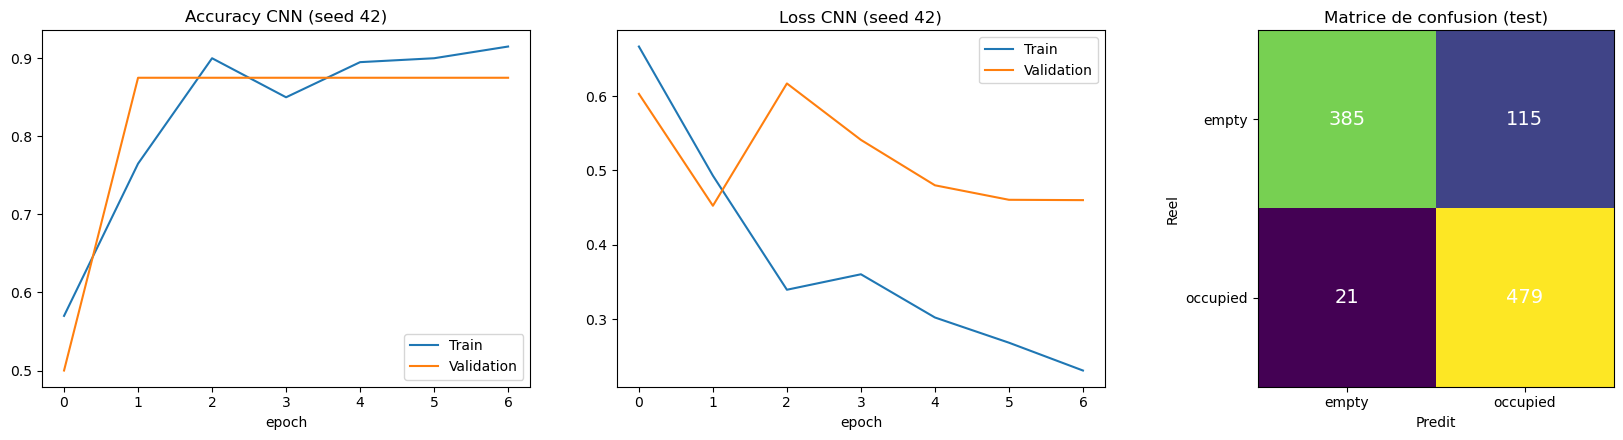

              precision    recall  f1-score   support

       empty     0.9483    0.7700    0.8499       500
    occupied     0.8064    0.9580    0.8757       500

    accuracy                         0.8640      1000
   macro avg     0.8773    0.8640    0.8628      1000
weighted avg     0.8773    0.8640    0.8628      1000



In [8]:
res0 = DL[DRAW_SEEDS[0]]
h = res0["history"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(h["accuracy"], label="Train"); axes[0].plot(h["val_accuracy"], label="Validation")
axes[0].set_title(f"Accuracy CNN (seed {res0['seed']})"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(h["loss"], label="Train"); axes[1].plot(h["val_loss"], label="Validation")
axes[1].set_title(f"Loss CNN (seed {res0['seed']})"); axes[1].set_xlabel("epoch"); axes[1].legend()

cm = confusion_matrix(res0["y_true"], res0["y_pred"])
axes[2].imshow(cm, cmap="viridis")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha="center", va="center", color="w", fontsize=14)
axes[2].set_xticks([0, 1], CLASS_NAMES); axes[2].set_yticks([0, 1], CLASS_NAMES)
axes[2].set_xlabel("Predit"); axes[2].set_ylabel("Reel"); axes[2].set_title("Matrice de confusion (test)")
fig.tight_layout()
fig.savefig(os.path.join(RESULT_DIR, "cnn_courbes_confusion.png"), dpi=150)
plt.show()

print(classification_report(res0["y_true"], res0["y_pred"], target_names=CLASS_NAMES, digits=4))

## 7) Anciennes méthodes sur les mêmes tirages (1-NN + distance SAD)

- **même budget** : 100 images / classe en entraînement (comme le CNN) ;
- **ancien protocole** : 3682 images / classe (celui de `parking_v6.py`), même jeu de test de 1000 images.

In [9]:
def knn_sad_accuracy(key, tr_idx, tr_y, te_idx, te_y):
    """1-NN avec distance SAD (Manhattan), equivalent a classify_vector_fast de parking_v6.py."""
    F = FEATS[key]
    nearest, _ = pairwise_distances_argmin_min(F[te_idx], F[tr_idx], metric="manhattan")
    return float((tr_y[nearest] == te_y).mean())

rows = []                                          # (seed, methode, protocole, accuracy)
for seed in DRAW_SEEDS:
    s = SPLITS[seed]
    te_idx, te_y = flat(s["test"])
    rows.append((seed, "CNN (deep learning)", "100/classe", DL[seed]["accuracy"]))
    if seed in DL_FULL:
        rows.append((seed, "CNN (deep learning)", "3682/classe (ancien)", DL_FULL[seed]["accuracy"]))
    for protocole, part in (("100/classe", "train"), ("3682/classe (ancien)", "train_full")):
        tr_idx, tr_y = flat(s[part])
        with old.timer(f"1-NN SAD, seed={seed}, {protocole}"):
            for key, (label, _) in METHODS.items():
                rows.append((seed, label, protocole, knn_sad_accuracy(key, tr_idx, tr_y, te_idx, te_y)))

df = pd.DataFrame(rows, columns=["seed", "methode", "protocole", "accuracy"])
df.to_csv(os.path.join(RESULT_DIR, "comparaison_tirages.csv"), index=False)

summary = (df.groupby(["protocole", "methode"], sort=False)["accuracy"]
             .agg(moyenne="mean", ecart_type=lambda x: np.std(x), minimum="min", maximum="max"))
(summary * 100).round(2)

[timer] 1-NN SAD, seed=42, 100/classe...
[timer] 1-NN SAD, seed=42, 100/classe termine en 0.11 s
[timer] 1-NN SAD, seed=42, 3682/classe (ancien)...


[timer] 1-NN SAD, seed=42, 3682/classe (ancien) termine en 2.24 s
[timer] 1-NN SAD, seed=1, 100/classe...
[timer] 1-NN SAD, seed=1, 100/classe termine en 0.06 s
[timer] 1-NN SAD, seed=1, 3682/classe (ancien)...


[timer] 1-NN SAD, seed=1, 3682/classe (ancien) termine en 2.24 s
[timer] 1-NN SAD, seed=2, 100/classe...
[timer] 1-NN SAD, seed=2, 100/classe termine en 0.06 s
[timer] 1-NN SAD, seed=2, 3682/classe (ancien)...


[timer] 1-NN SAD, seed=2, 3682/classe (ancien) termine en 2.22 s
[timer] 1-NN SAD, seed=3, 100/classe...
[timer] 1-NN SAD, seed=3, 100/classe termine en 0.06 s
[timer] 1-NN SAD, seed=3, 3682/classe (ancien)...


[timer] 1-NN SAD, seed=3, 3682/classe (ancien) termine en 2.23 s
[timer] 1-NN SAD, seed=4, 100/classe...
[timer] 1-NN SAD, seed=4, 100/classe termine en 0.07 s
[timer] 1-NN SAD, seed=4, 3682/classe (ancien)...


[timer] 1-NN SAD, seed=4, 3682/classe (ancien) termine en 2.24 s


moyenne  ecart_type  \
protocole            methode                                                
100/classe           CNN (deep learning)                90.86        2.56   
3682/classe (ancien) CNN (deep learning)                99.48        0.17   
100/classe           LBP gris                           91.34        0.89   
                     LBP mosaique RGB (v5)              91.52        0.89   
                     LBP par plan RGB                   91.52        1.17   
                     LBP multi-echelle 2x2 (4 hist.)    91.86        1.40   
                     LBP pyramide 1-2-4 (ancien)        92.66        1.23   
3682/classe (ancien) LBP gris                           99.62        0.15   
                     LBP mosaique RGB (v5)              99.66        0.14   
                     LBP par plan RGB                   99.74        0.12   
                     LBP multi-echelle 2x2 (4 hist.)    99.86        0.08   
                     LBP pyramide 1-2-4 (ancien)        99.92        0.10   

                                                      minimum  maximum  
protocole            methode                                            
100/classe           CNN (deep learning)                 86.4     93.3  
3682/classe (ancien) CNN (deep learning)                 99.2     99.7  
100/classe           LBP gris                            89.8     92.5  
                     LBP mosaique RGB (v5)               90.0     92.7  
                     LBP par plan RGB                    89.2     92.3  
                     LBP multi-echelle 2x2 (4 hist.)     89.9     93.8  
                     LBP pyramide 1-2-4 (ancien)         90.5     94.3  
3682/classe (ancien) LBP gris                            99.4     99.8  
                     LBP mosaique RGB (v5)               99.5     99.8  
                     LBP par plan RGB                    99.6     99.9  
                     LBP multi-echelle 2x2 (4 hist.)     99.8    100.0  
                     LBP pyramide 1-2-4 (ancien)         99.8    100.0

## 8) Graphiques : accuracy par tirage et **moyenne**

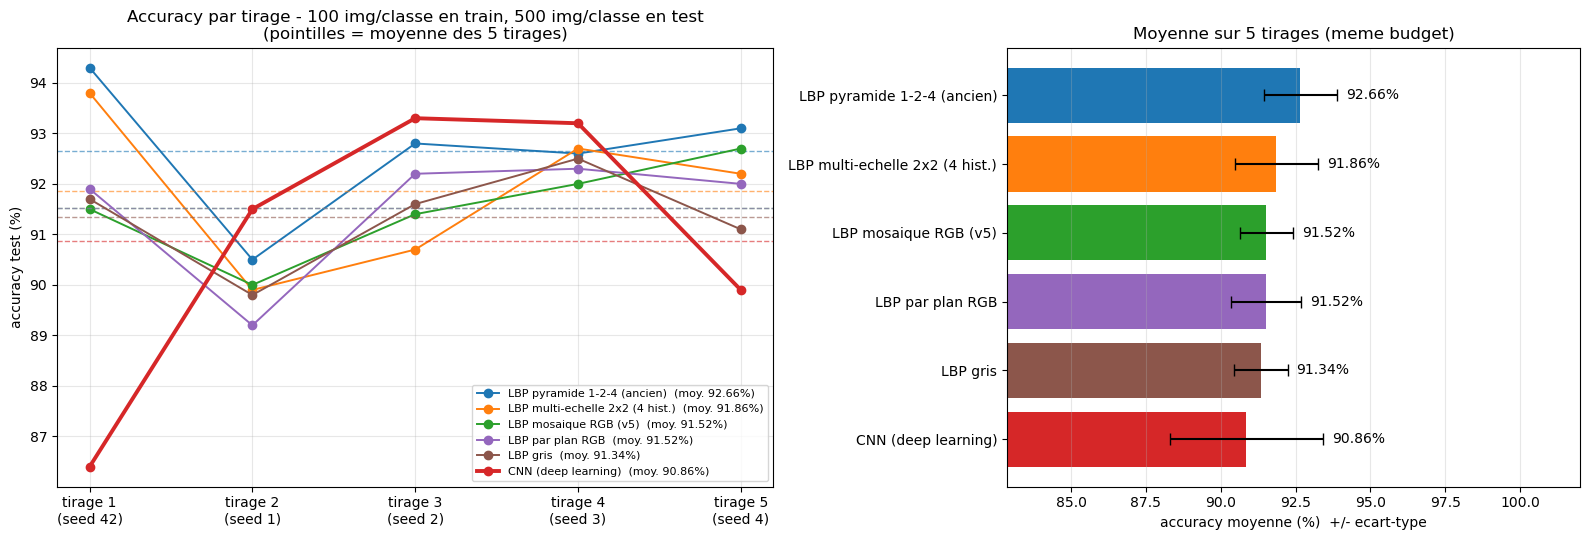

In [10]:
def order(protocole):
    m = df[df.protocole == protocole].groupby("methode", sort=False)["accuracy"].mean()
    return list(m.sort_values(ascending=False).index)

# ---- Graphe 1 : meme budget (100 images / classe) : accuracy par tirage + moyenne ----
p = "100/classe"
methods = order(p)
colors = {m: ("tab:red" if m.startswith("CNN") else c)
          for m, c in zip(methods, plt.cm.tab10(np.linspace(0, 1, 10))[[0, 1, 2, 4, 5, 6][:len(methods)]])}
colors["CNN (deep learning)"] = "tab:red"

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
x = np.arange(len(DRAW_SEEDS))
for m in methods:
    sub = df[(df.protocole == p) & (df.methode == m)].set_index("seed").loc[DRAW_SEEDS, "accuracy"] * 100
    lw = 2.8 if m.startswith("CNN") else 1.4
    ax.plot(x, sub.values, marker="o", lw=lw, color=colors[m], label=f"{m}  (moy. {sub.mean():.2f}%)")
    ax.axhline(sub.mean(), color=colors[m], ls="--", lw=1, alpha=0.6)
ax.set_xticks(x, [f"tirage {i + 1}\n(seed {s})" for i, s in enumerate(DRAW_SEEDS)])
ax.set_ylabel("accuracy test (%)")
ax.set_title(f"Accuracy par tirage - {N_TRAIN_PER_CLASS} img/classe en train, {N_TEST_PER_CLASS} img/classe en test\n(pointilles = moyenne des 5 tirages)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

ax = axes[1]
means = [df[(df.protocole == p) & (df.methode == m)].accuracy.mean() * 100 for m in methods]
stds = [df[(df.protocole == p) & (df.methode == m)].accuracy.std(ddof=0) * 100 for m in methods]
ypos = np.arange(len(methods))[::-1]
ax.barh(ypos, means, xerr=stds, capsize=4, color=[colors[m] for m in methods])
for y, m_, s_ in zip(ypos, means, stds):
    ax.text(m_ + s_ + 0.3, y, f"{m_:.2f}%", va="center")
ax.set_yticks(ypos, methods)
ax.set_xlim(max(0, min(means) - 8), 102)
ax.set_xlabel("accuracy moyenne (%)  +/- ecart-type")
ax.set_title("Moyenne sur 5 tirages (meme budget)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULT_DIR, "comparaison_moyenne_100.png"), dpi=150)
plt.show()

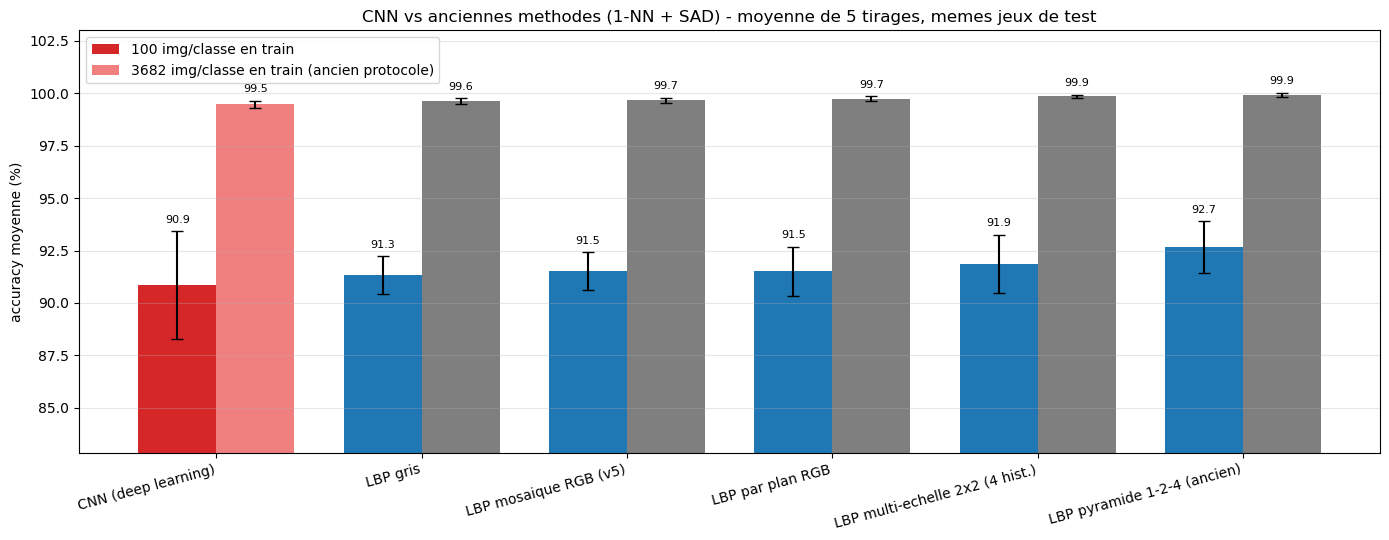

In [11]:
# ---- Graphe 2 : CNN contre les anciennes methodes, 100/classe ET protocole complet ----
labels_m = [m for m in METHODS.values()]
names = [l for l, _ in labels_m]
def mean_std(protocole, m):
    v = df[(df.protocole == protocole) & (df.methode == m)].accuracy.values * 100
    return v.mean(), v.std()

fig, ax = plt.subplots(figsize=(14, 5.5))
groups = [("CNN (deep learning)", None)] + [(n, None) for n in names]
xs = np.arange(len(groups))
w = 0.38
m100 = [mean_std("100/classe", g)[0] for g, _ in groups]; s100 = [mean_std("100/classe", g)[1] for g, _ in groups]
b1 = ax.bar(xs - w / 2, m100, w, yerr=s100, capsize=4, label="100 img/classe en train",
            color=["tab:red"] + ["tab:blue"] * len(names))
has_full = lambda g: ((df.protocole == "3682/classe (ancien)") & (df.methode == g)).any()
full = [mean_std("3682/classe (ancien)", g) if has_full(g) else (np.nan, 0) for g, _ in groups]
b2 = ax.bar(xs + w / 2, [f[0] for f in full], w, yerr=[f[1] for f in full], capsize=4,
            label="3682 img/classe en train (ancien protocole)", color=["lightcoral"] + ["tab:gray"] * len(names))
for bars, errs in ((b1, s100), (b2, [f[1] for f in full])):
    for b, e in zip(bars, errs):
        if not np.isnan(b.get_height()):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + e + 0.4, f"{b.get_height():.1f}", ha="center", fontsize=8)
allv = [v for v in m100 + [f[0] for f in full] if not np.isnan(v)]
ax.set_ylim(max(0, min(allv) - 8), 103)
ax.set_xticks(xs, [g for g, _ in groups], rotation=15, ha="right")
ax.set_ylabel("accuracy moyenne (%)")
ax.set_title("CNN vs anciennes methodes (1-NN + SAD) - moyenne de 5 tirages, memes jeux de test")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULT_DIR, "comparaison_cnn_anciennes_methodes.png"), dpi=150)
plt.show()

## 9) Comparaison ciblée : **CNN vs méthode pyramide LBP 1-2-4**

Deux classes seulement (**empty / occupied**, soit free / busy). Mêmes tirages, mêmes 1000 images de test pour les deux méthodes.
- **100 img/classe** : les deux méthodes sont entraînées sur les mêmes 100 images / classe ;
- **protocole complet** : pyramide sur 3682 img/classe (ancien protocole) ; CNN sur 3482 img/classe + 200 img/classe de validation
  (early stopping), tirées dans ces mêmes 3682 images.

In [12]:
PYR = METHODS["pyramid"][0]
CNN = "CNN (deep learning)"

def knn_sad_predict(key, tr_idx, tr_y, te_idx):
    nearest, _ = pairwise_distances_argmin_min(FEATS[key][te_idx], FEATS[key][tr_idx], metric="manhattan")
    return tr_y[nearest]

protos = ["100/classe"] + (["3682/classe (ancien)"] if DL_FULL else [])
tab = (df[df.methode.isin([CNN, PYR])]
       .pivot_table(index=["protocole", "seed"], columns="methode", values="accuracy") * 100)
tab["CNN - pyramide (pts)"] = tab[CNN] - tab[PYR]
tab = tab.reindex(pd.MultiIndex.from_product([protos, DRAW_SEEDS], names=["protocole", "seed"])).round(2)
tab.to_csv(os.path.join(RESULT_DIR, "cnn_vs_pyramide.csv"))
print(tab.to_string())

print("\n=== Moyenne sur les 5 tirages (+/- ecart-type) ===")
for pr in protos:
    for m in (CNN, PYR):
        v = df[(df.protocole == pr) & (df.methode == m)].accuracy.values * 100
        print(f"  {pr:<22} {m:<30} {v.mean():6.2f}%  +/- {v.std():.2f}")
    d = tab.loc[pr, "CNN - pyramide (pts)"]
    print(f"  {pr:<22} ecart moyen CNN - pyramide = {d.mean():+.2f} pts "
          f"(le CNN gagne {int((d > 0).sum())}/{len(d)} tirages)")

methode                    CNN (deep learning)  LBP pyramide 1-2-4 (ancien)  CNN - pyramide (pts)
protocole            seed                                                                        
100/classe           42                   86.4                         94.3                  -7.9
                     1                    91.5                         90.5                   1.0
                     2                    93.3                         92.8                   0.5
                     3                    93.2                         92.6                   0.6
                     4                    89.9                         93.1                  -3.2
3682/classe (ancien) 42                   99.5                         99.8                  -0.3
                     1                    99.7                        100.0                  -0.3
                     2                    99.6                        100.0                  -0.4
                    

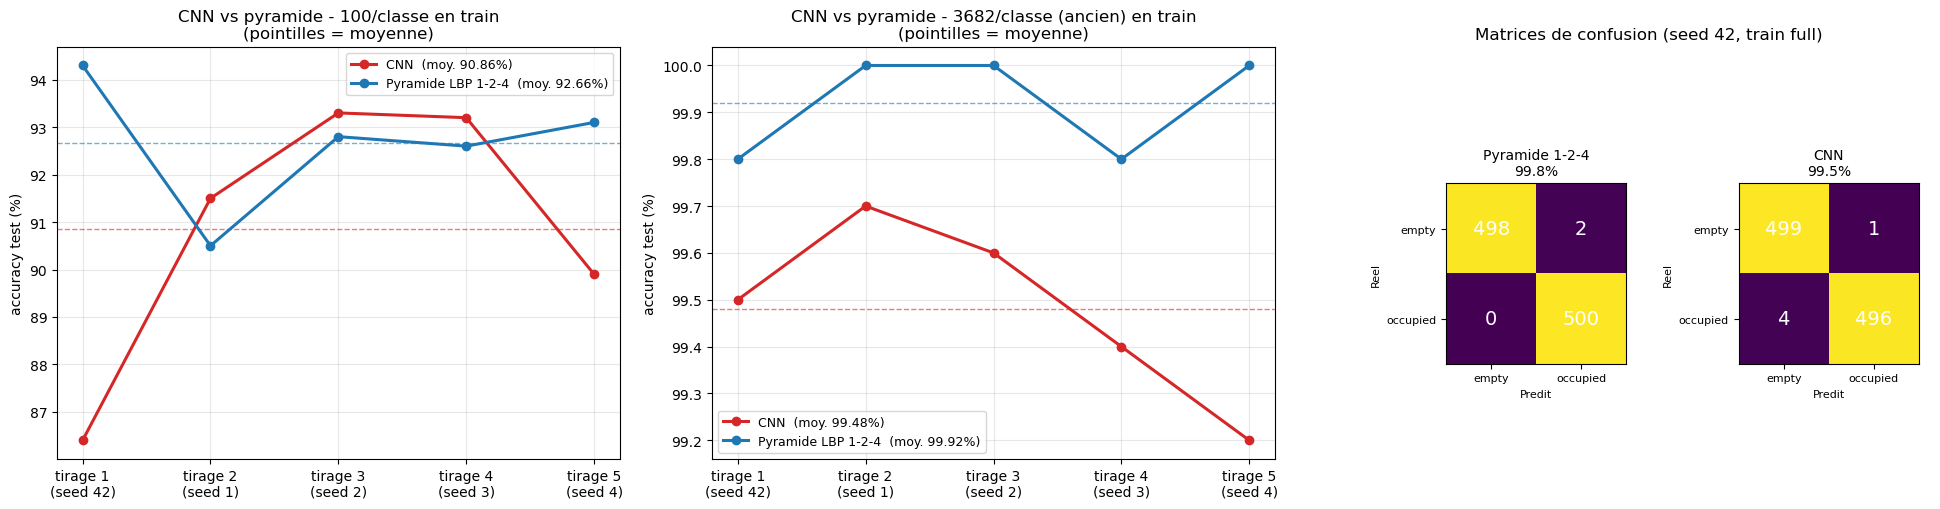

In [13]:
fig, axes = plt.subplots(1, len(protos) + 1, figsize=(6.5 * (len(protos) + 1), 5.2))
cols = {CNN: "tab:red", PYR: "tab:blue"}
short = {CNN: "CNN", PYR: "Pyramide LBP 1-2-4"}
x = np.arange(len(DRAW_SEEDS))

for ax, pr in zip(axes, protos):
    for m in (CNN, PYR):
        v = df[(df.protocole == pr) & (df.methode == m)].set_index("seed").loc[DRAW_SEEDS, "accuracy"] * 100
        ax.plot(x, v.values, marker="o", lw=2.2, color=cols[m], label=f"{short[m]}  (moy. {v.mean():.2f}%)")
        ax.axhline(v.mean(), color=cols[m], ls="--", lw=1, alpha=0.6)
    ax.set_xticks(x, [f"tirage {i + 1}\n(seed {s})" for i, s in enumerate(DRAW_SEEDS)])
    ax.set_ylabel("accuracy test (%)"); ax.set_title(f"CNN vs pyramide - {pr} en train\n(pointilles = moyenne)")
    ax.legend(loc="best", fontsize=9); ax.grid(alpha=0.3)

# matrices de confusion (tirage officiel) : pyramide vs CNN, protocole le plus complet
seed0 = DRAW_SEEDS[0]
part = "train_full" if DL_FULL else "train"
tr_idx, tr_y = flat(SPLITS[seed0][part]); te_idx, te_y = flat(SPLITS[seed0]["test"])
pred_pyr = knn_sad_predict("pyramid", tr_idx, tr_y, te_idx)
pred_cnn = np.array((DL_FULL if DL_FULL else DL)[seed0]["y_pred"])
ax = axes[-1]
ax.axis("off")
for k, (name, pred) in enumerate((("Pyramide 1-2-4", pred_pyr), ("CNN", pred_cnn))):
    cm = confusion_matrix(te_y, pred)
    sub = ax.inset_axes([0.14 + 0.52 * k, 0.15, 0.32, 0.6])
    sub.imshow(cm, cmap="viridis")
    for i in range(2):
        for j in range(2):
            sub.text(j, i, str(cm[i, j]), ha="center", va="center", color="w", fontsize=14)
    sub.set_xticks([0, 1], CLASS_NAMES, fontsize=8); sub.set_yticks([0, 1], CLASS_NAMES, fontsize=8)
    sub.set_xlabel("Predit", fontsize=8); sub.set_ylabel("Reel", fontsize=8)
    sub.set_title(f"{name}\n{(np.trace(cm) / cm.sum()) * 100:.1f}%", fontsize=10)
ax.set_title(f"Matrices de confusion (seed {seed0}, {part.replace('_', ' ')})")
fig.tight_layout()
fig.savefig(os.path.join(RESULT_DIR, "cnn_vs_pyramide.png"), dpi=150)
plt.show()

## 10) Résumé chronométré

In [14]:
print("=== Chronometre par etape ===")
total = 0.0
for label, elapsed in old.TIMINGS.items():
    print(f"  {label:<55} {elapsed:>7.2f} s")
    total += elapsed
print(f"  {'TOTAL':<55} {total:>7.2f} s")

print("\n=== Temps d'entrainement du CNN par tirage (1er entrainement, meme si relu du cache) ===")
for name, D in (("100/classe", DL), ("protocole complet", DL_FULL)):
    for seed in (DRAW_SEEDS if D else []):
        print(f"  {name:<18} seed={seed:<3} {D[seed]['epochs_reelles']:>2} epochs  {D[seed]['train_time_s']:>7.1f} s  "
              f"accuracy = {D[seed]['accuracy'] * 100:.2f}%")
accs = np.array([DL[s]["accuracy"] for s in DRAW_SEEDS]) * 100
print(f"\nCNN : accuracy moyenne = {accs.mean():.2f}%  (ecart-type = {accs.std():.2f} pts, {len(accs)} tirages)")

=== Chronometre par etape ===
  Listage des images (A et B combines)                       0.02 s
  Chargement des images                                      0.11 s
  Caracteristiques LBP (toutes les images)                   0.08 s
  Entrainement CNN (5 tirages, 100 img/classe)               0.00 s
  Entrainement CNN (5 tirages, protocole complet)            0.00 s
  1-NN SAD, seed=42, 100/classe                              0.11 s
  1-NN SAD, seed=42, 3682/classe (ancien)                    2.24 s
  1-NN SAD, seed=1, 100/classe                               0.06 s
  1-NN SAD, seed=1, 3682/classe (ancien)                     2.24 s
  1-NN SAD, seed=2, 100/classe                               0.06 s
  1-NN SAD, seed=2, 3682/classe (ancien)                     2.22 s
  1-NN SAD, seed=3, 100/classe                               0.06 s
  1-NN SAD, seed=3, 3682/classe (ancien)                     2.23 s
  1-NN SAD, seed=4, 100/classe                               0.07 s
  1-NN SAD, seed=4